# 🧪 Amazon Reviews — Model Experimentation

**Goal:** Benchmark multiple classifiers on the preprocessed features,
compare their performance across all three sentiment classes, and identify
the best candidate for hyperparameter tuning.

### Strategy
| Step | Action |
|---|---|
| 1 | Load featurized train + val splits |
| 2 | Re-attach `classWeight` column |
| 3 | Train 4 classifiers with default params + class weights |
| 4 | Evaluate on val set — overall F1, accuracy, per-class P/R/F1 |
| 5 | Plot confusion matrices and F1 comparison |
| 6 | Declare winner → pass to `04-train-best-model.ipynb` |

### Classifiers
- **Logistic Regression** — strong baseline for TF-IDF text features
- **Linear SVC** — effective for high-dimensional sparse text, fast
- **Naive Bayes (Multinomial)** — classic text classifier, very fast
- **Random Forest** — non-linear, but slower on sparse high-dim data

> **⚠️ Val set is for model selection only.**  
> The test set is never touched in this notebook.


---
## 0. Setup & SparkSession

In [1]:
import os
import time
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml.classification import (
    LogisticRegression,
    LinearSVC,
    OneVsRest,
    NaiveBayes,
    RandomForestClassifier,
)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml import Pipeline

# ── Paths ────────────────────────────────────────────────────────
DATA_DIR       = '../data'
TRAIN_FEAT_DIR = os.path.join(DATA_DIR, 'train_feat')
VAL_FEAT_DIR   = os.path.join(DATA_DIR, 'val_feat')

# ── Aesthetics ───────────────────────────────────────────────────
PALETTE   = {'negative': '#e74c3c', 'neutral': '#f39c12', 'positive': '#2ecc71'}
COLOR_MAP = [PALETTE['negative'], PALETTE['neutral'], PALETTE['positive']]
sns.set_style('whitegrid')
plt.rcParams.update({'axes.titlesize': 13, 'axes.labelsize': 11})

# ── SparkSession ─────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName('AmazonReviews-ModelExperimenting')
    .master('local[*]')
    .config('spark.driver.memory', '6g')
    .config('spark.sql.shuffle.partitions', '8')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'Spark {spark.version} ready.')


26/05/07 14:43:59 WARN Utils: Your hostname, regisx001 resolves to a loopback address: 127.0.1.1; using 192.168.11.227 instead (on interface wlp1s0)
26/05/07 14:43:59 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/07 14:44:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 3.5.1 ready.


---
## 1. Load Featurized Splits

In [2]:
train_feat = spark.read.parquet(TRAIN_FEAT_DIR)
val_feat   = spark.read.parquet(VAL_FEAT_DIR)

print(f'Train rows : {train_feat.count():,}')
print(f'Val rows   : {val_feat.count():,}')
train_feat.printSchema()


Train rows : 310,886
Val rows   : 39,023
root
 |-- Id: integer (nullable = true)
 |-- ProductId: string (nullable = true)
 |-- UserId: string (nullable = true)
 |-- Score: string (nullable = true)
 |-- Time: string (nullable = true)
 |-- Sentiment: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- features: vector (nullable = true)
 |-- classWeight: double (nullable = true)



26/05/07 14:44:12 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [3]:
# Verify classWeight column is present (added in preprocessing)
# If loading from a fresh session and column is missing, recompute it here
if 'classWeight' not in train_feat.columns:
    print('  classWeight missing — recomputing...')
    from pyspark.sql.functions import count as spark_count

    n_total = train_feat.count()
    n_classes = 3
    class_counts = (
        train_feat.groupBy('label')
        .agg(spark_count('label').alias('cnt'))
        .collect()
    )
    weight_map = {r['label']: n_total / (n_classes * r['cnt']) for r in class_counts}

    def add_weights(df, wmap):
        expr = None
        for lbl, w in wmap.items():
            cond = when(col('label') == lbl, float(w))
            expr = cond if expr is None else expr.when(col('label') == lbl, float(w))
        return df.withColumn('classWeight', expr.otherwise(1.0))

    train_feat = add_weights(train_feat, weight_map)
    val_feat   = add_weights(val_feat,   weight_map)
    print(' classWeight recomputed.')
    for r in sorted(weight_map.items()):
        print(f'  label={r[0]}: weight={r[1]:.4f}')
else:
    print(' classWeight column found.')
    train_feat.groupBy('label', 'classWeight').count().orderBy('label').show()


 classWeight column found.


+-----+------------------+------+
|label|       classWeight| count|
+-----+------------------+------+
|    0|2.3366102968808717| 44350|
|    1| 4.414238655080366| 23476|
|    2|0.4263501467401739|243060|
+-----+------------------+------+



---
## 2. Evaluation Helpers

In [4]:
def get_metrics(predictions, label_col='label', pred_col='prediction'):
    """
    Returns a dict with overall F1, accuracy, and per-class P/R/F1.
    """
    def evaluator(metric, label=None):
        kwargs = dict(predictionCol=pred_col, labelCol=label_col, metricName=metric)
        if label is not None:
            kwargs['metricLabel'] = label
        return MulticlassClassificationEvaluator(**kwargs).evaluate(predictions)

    metrics = {
        'f1':       evaluator('f1'),
        'accuracy': evaluator('accuracy'),
    }
    label_names = {0: 'negative', 1: 'neutral', 2: 'positive'}
    for lbl, name in label_names.items():
        metrics[f'precision_{name}'] = evaluator('precisionByLabel', lbl)
        metrics[f'recall_{name}']    = evaluator('recallByLabel',    lbl)
        metrics[f'f1_{name}']        = evaluator('fMeasureByLabel',  lbl)
    return metrics


def print_metrics(name, metrics):
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(f'  Overall  — F1: {metrics["f1"]:.4f}  |  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  {"─"*51}')
    for cls in ['negative', 'neutral', 'positive']:
        p = metrics[f'precision_{cls}']
        r = metrics[f'recall_{cls}']
        f = metrics[f'f1_{cls}']
        print(f'  {cls:>8s}  — P: {p:.4f}  R: {r:.4f}  F1: {f:.4f}')

print(' Evaluation helpers ready.')


 Evaluation helpers ready.


In [5]:
def get_confusion_matrix(predictions, label_col='label', pred_col='prediction'):
    """Returns a 3x3 pandas DataFrame confusion matrix."""
    cm = (
        predictions
        .groupBy(label_col, pred_col)
        .count()
        .toPandas()
        .pivot(index=label_col, columns=pred_col, values='count')
        .fillna(0).astype(int)
    )
    # Ensure all 3 classes appear even if a model never predicts one
    for c in [0, 1, 2]:
        if c not in cm.columns: cm[c] = 0
        if c not in cm.index:   cm.loc[c] = 0
    return cm.sort_index(axis=0).sort_index(axis=1)

print(' Confusion matrix helper ready.')


 Confusion matrix helper ready.


---
## 3. Define Classifiers

All models receive:
- `featuresCol='features'` — the TF-IDF vector from preprocessing
- `labelCol='label'` — 0/1/2 numeric label
- `weightCol='classWeight'` — inverse-frequency class weights *(where supported)*

> **Note:** `NaiveBayes` and `RandomForestClassifier` in PySpark do **not** support
> `weightCol` in all versions. We flag this in the results.


In [ ]:
MODELS = {
    'LogisticRegression': LogisticRegression(
        featuresCol='features',
        labelCol='label',
        weightCol='classWeight',   #  supported
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0.0,
        family='multinomial',
    ),
    'LinearSVC': OneVsRest(
        # weightCol goes on OneVsRest, NOT on LinearSVC
        classifier=LinearSVC(
            maxIter=100,
            regParam=0.01,
            # ❌ NO weightCol here — OvR handles it at the outer level
        ),
        featuresCol='features',
        labelCol='label',
        weightCol='classWeight',   
        ),
    'NaiveBayes': NaiveBayes(
        featuresCol='features',
        labelCol='label',
        # weightCol not reliably supported — omitted
        modelType='multinomial',
        smoothing=1.0,
    ),
#     'RandomForest': RandomForestClassifier(
#     featuresCol='features',
#     labelCol='label',
#     numTrees=10,        # was 100 → 10x faster
#     maxDepth=5,         # was 10  → 32x fewer nodes
#     maxBins=32,
#     featureSubsetStrategy='sqrt',
#     seed=42,
# ),
}

print('Models defined:')
for name in MODELS:
    print(f'  - {name}')


Models defined:
  - LogisticRegression
  - NaiveBayes
  - RandomForest


---
## 4. Train & Evaluate All Models

Each model is trained on `train_feat` and evaluated on `val_feat`.
Training time is recorded for practical comparison.


In [7]:
results       = []
conf_matrices = {}
trained_models = {}

for name, clf in MODELS.items():
    print(f'\nTraining {name}...')
    t0 = time.time()

    fitted  = clf.fit(train_feat)        # clean — no wrapping logic needed
    elapsed = time.time() - t0

    preds = fitted.transform(val_feat)
    m     = get_metrics(preds)
    cm    = get_confusion_matrix(preds)

    results.append({
        'Model':          name,
        'F1':             m['f1'],
        'Accuracy':       m['accuracy'],
        'F1_negative':    m['f1_negative'],
        'F1_neutral':     m['f1_neutral'],
        'F1_positive':    m['f1_positive'],
        'Train time (s)': round(elapsed, 1),
    })
    conf_matrices[name]   = cm
    trained_models[name]  = fitted

    print_metrics(name, m)
    print(f'  ⏱  Training time: {elapsed:.1f}s')


Training LogisticRegression...


26/05/05 19:35:34 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/05/05 19:35:39 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors
26/05/05 19:36:18 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:19 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:20 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:20 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:20 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:20 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:21 W


  LogisticRegression
  Overall  — F1: 0.8038  |  Accuracy: 0.7940
  ───────────────────────────────────────────────────
  negative  — P: 0.5574  R: 0.6302  F1: 0.5916
   neutral  — P: 0.2261  R: 0.2944  F1: 0.2558
  positive  — P: 0.9172  R: 0.8699  F1: 0.8929
  ⏱  Training time: 47.7s

Training NaiveBayes...


26/05/05 19:36:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:24 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:25 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:26 WARN DAGScheduler: Broadcasting large task binary with size 2.4 MiB
26/05/05 19:36:27 WARN DAGScheduler: Broadcasting larg


  NaiveBayes
  Overall  — F1: 0.8002  |  Accuracy: 0.7788
  ───────────────────────────────────────────────────
  negative  — P: 0.5528  R: 0.6665  F1: 0.6043
   neutral  — P: 0.2330  R: 0.4227  F1: 0.3004
  positive  — P: 0.9379  R: 0.8322  F1: 0.8819
  ⏱  Training time: 1.8s

Training RandomForest...


26/05/05 19:36:28 WARN DAGScheduler: Broadcasting large task binary with size 1079.1 KiB
26/05/05 19:36:47 WARN DAGScheduler: Broadcasting large task binary with size 2.5 MiB
26/05/05 19:36:51 WARN MemoryStore: Not enough space to cache rdd_607_1 in memory! (computed 362.9 MiB so far)
26/05/05 19:36:51 WARN BlockManager: Persisting block rdd_607_1 to disk instead.
26/05/05 19:36:51 WARN MemoryStore: Not enough space to cache rdd_607_0 in memory! (computed 362.9 MiB so far)
26/05/05 19:36:51 WARN BlockManager: Persisting block rdd_607_0 to disk instead.
26/05/05 19:36:51 WARN MemoryStore: Not enough space to cache rdd_607_2 in memory! (computed 362.9 MiB so far)
26/05/05 19:36:51 WARN MemoryStore: Not enough space to cache rdd_607_3 in memory! (computed 362.9 MiB so far)
26/05/05 19:36:51 WARN BlockManager: Persisting block rdd_607_2 to disk instead.
26/05/05 19:36:51 WARN BlockManager: Persisting block rdd_607_3 to disk instead.
26/05/05 19:36:52 WARN MemoryStore: Not enough space to c


  RandomForest
  Overall  — F1: 0.6914  |  Accuracy: 0.7857
  ───────────────────────────────────────────────────
  negative  — P: 0.0000  R: 0.0000  F1: 0.0000
   neutral  — P: 0.0000  R: 0.0000  F1: 0.0000
  positive  — P: 0.7857  R: 1.0000  F1: 0.8800
  ⏱  Training time: 270.9s


---
## 5. Results Summary

In [8]:
results_df = (
    pd.DataFrame(results)
    .sort_values('F1', ascending=False)
    .reset_index(drop=True)
)

# Format for display
display_cols = ['Model', 'F1', 'Accuracy', 'F1_negative', 'F1_neutral', 'F1_positive', 'Train time (s)']
print('=== Model Performance on Validation Set ===')
print(results_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

best_model_name = results_df.iloc[0]['Model']
print(f'\nBest model by overall F1: {best_model_name}')


=== Model Performance on Validation Set ===
             Model     F1  Accuracy  F1_negative  F1_neutral  F1_positive  Train time (s)
LogisticRegression 0.8038    0.7940       0.5916      0.2558       0.8929         47.7000
        NaiveBayes 0.8002    0.7788       0.6043      0.3004       0.8819          1.8000
      RandomForest 0.6914    0.7857       0.0000      0.0000       0.8800        270.9000

Best model by overall F1: LogisticRegression


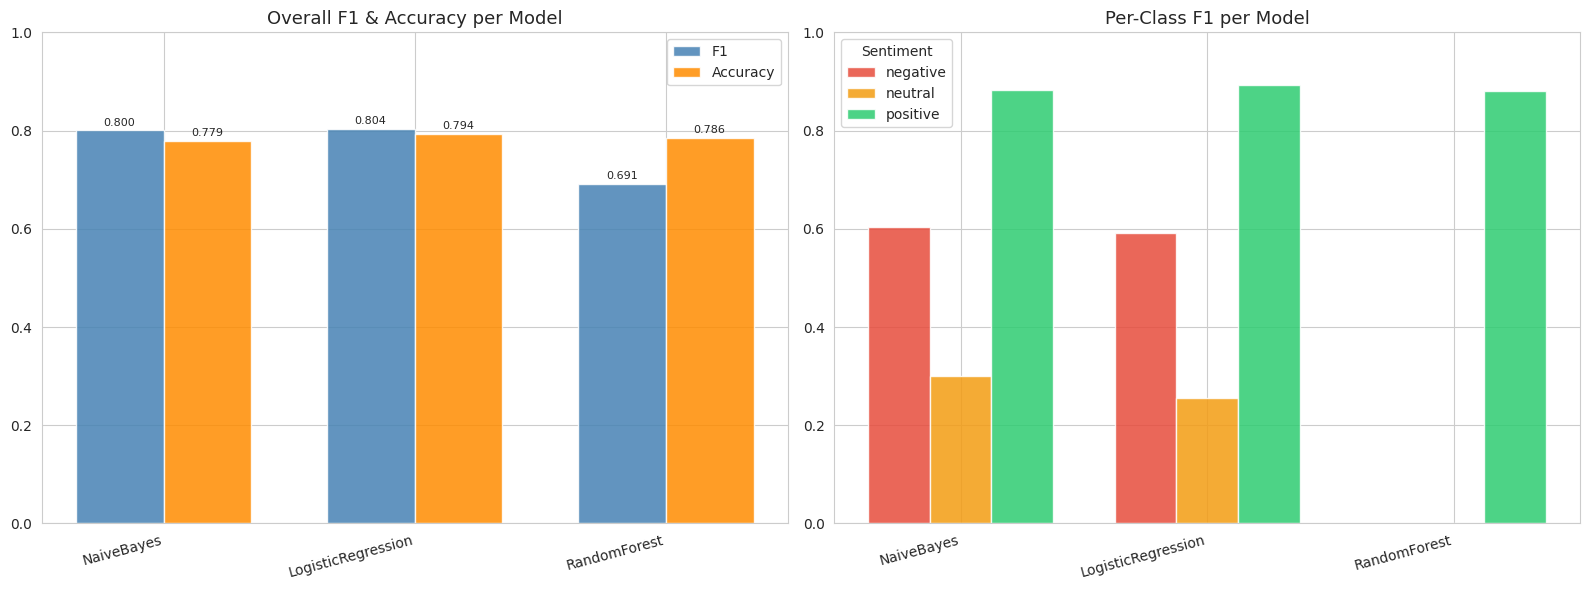

In [16]:
# ── Bar chart: F1 per model per class ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall F1 & Accuracy
x = np.arange(len(results_df))
w = 0.35
axes[0].bar(x - w/2, results_df['F1'],       width=w, label='F1',       color='steelblue',   alpha=0.85)
axes[0].bar(x + w/2, results_df['Accuracy'], width=w, label='Accuracy', color='darkorange', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[0].set_ylim(0, 1)
axes[0].set_title('Overall F1 & Accuracy per Model')
axes[0].legend()
for i, (f, a) in enumerate(zip(results_df['F1'], results_df['Accuracy'])):
    axes[0].text(i - w/2, f + 0.01, f'{f:.3f}', ha='center', fontsize=8)
    axes[0].text(i + w/2, a + 0.01, f'{a:.3f}', ha='center', fontsize=8)

# Per-class F1
x = np.arange(len(results_df))
w = 0.25
for i, (cls, color) in enumerate(zip(['negative', 'neutral', 'positive'], COLOR_MAP)):
    axes[1].bar(x + (i-1)*w, results_df[f'F1_{cls}'], width=w,
                label=cls, color=color, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Model'], rotation=15, ha='right')
axes[1].set_ylim(0, 1)
axes[1].set_title('Per-Class F1 per Model')
axes[1].legend(title='Sentiment')

plt.tight_layout()
plt.savefig('../figures/experiments/01_model_comparison.png', dpi=150)
plt.show()


---
## 6. Confusion Matrices

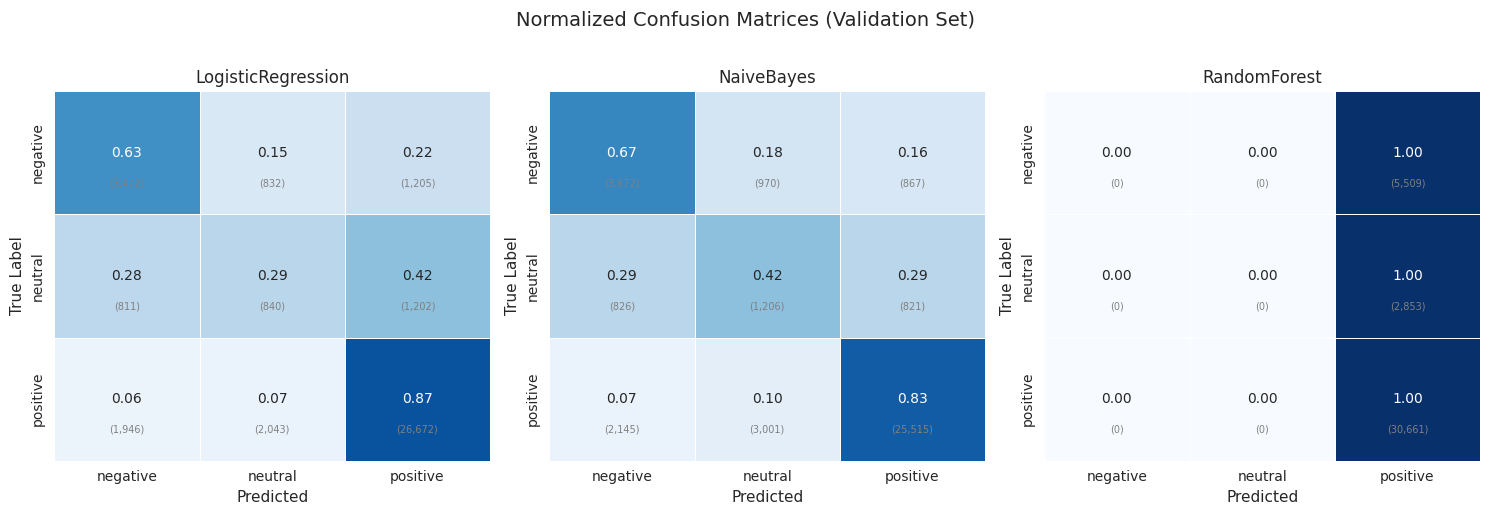

In [17]:
n_models = len(conf_matrices)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 5))
if n_models == 1:
    axes = [axes]

class_labels = ['negative', 'neutral', 'positive']

for ax, (name, cm) in zip(axes, conf_matrices.items()):
    # Normalize by true class (rows) for readability
    cm_norm = cm.div(cm.sum(axis=1), axis=0).round(2)
    sns.heatmap(
        cm_norm,
        annot=True, fmt='.2f',
        cmap='Blues',
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=ax,
        vmin=0, vmax=1,
        linewidths=0.5,
        cbar=False,
    )
    # Raw counts as secondary annotation
    for i in range(3):
        for j in range(3):
            ax.text(j + 0.5, i + 0.75, f'({cm.iloc[i, j]:,})',
                    ha='center', va='center', fontsize=7, color='gray')
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True Label')

plt.suptitle('Normalized Confusion Matrices (Validation Set)', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig('../figures/experiments/02_confusion_matrices.png', dpi=150)
plt.show()


---
## 7. Neutral Class Deep-Dive

The **neutral class** (score=3) is the hardest to classify because:
1. It's the **rarest** (~7% of data)
2. Its language overlaps with both positive and negative
3. Without class weights it gets almost entirely ignored

This section shows how well each model recovers the neutral class
after applying class weights.


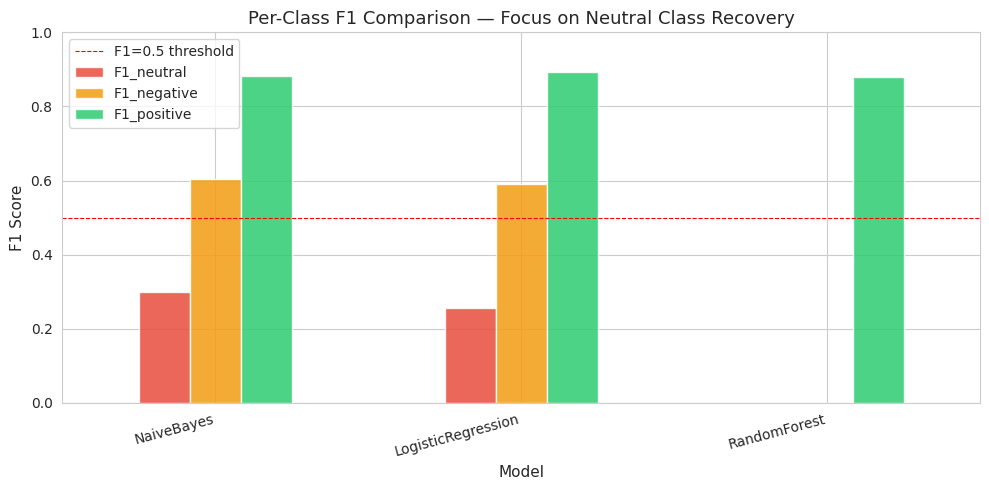


📊 Neutral class F1 ranking:
             Model  F1_neutral
        NaiveBayes    0.300374
LogisticRegression    0.255786
      RandomForest    0.000000


In [18]:
neutral_df = results_df[['Model', 'F1_neutral', 'F1_negative', 'F1_positive']].copy()
neutral_df = neutral_df.set_index('Model')

fig, ax = plt.subplots(figsize=(10, 5))
neutral_df.plot(kind='bar', ax=ax,
                color=COLOR_MAP,
                alpha=0.85, edgecolor='white')
ax.set_title('Per-Class F1 Comparison — Focus on Neutral Class Recovery')
ax.set_ylabel('F1 Score')
ax.set_ylim(0, 1)
ax.set_xticklabels(neutral_df.index, rotation=15, ha='right')
ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, label='F1=0.5 threshold')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/experiments/03_neutral_class_comparison.png', dpi=150)
plt.show()

print('\n📊 Neutral class F1 ranking:')
print(results_df[['Model', 'F1_neutral']].sort_values('F1_neutral', ascending=False).to_string(index=False))


---
## 8. Training Time vs F1 Trade-off

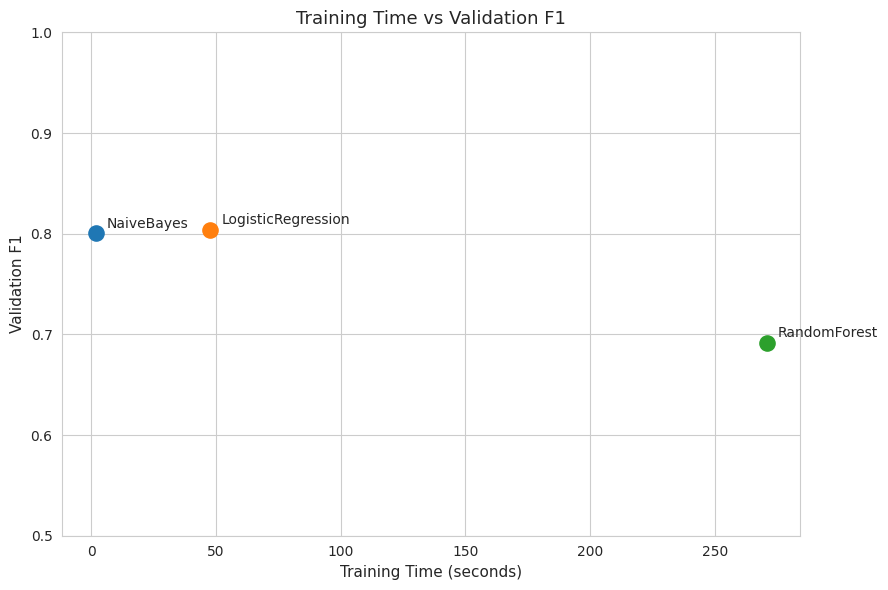

In [19]:
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in results_df.iterrows():
    ax.scatter(row['Train time (s)'], row['F1'], s=120, zorder=5)
    ax.annotate(
        row['Model'],
        (row['Train time (s)'], row['F1']),
        textcoords='offset points',
        xytext=(8, 4),
        fontsize=10
    )

ax.set_title('Training Time vs Validation F1')
ax.set_xlabel('Training Time (seconds)')
ax.set_ylabel('Validation F1')
ax.set_ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('../figures/experiments/04_time_vs_f1.png', dpi=150)
plt.show()


---
## 9. Best Model Decision

We select the best model based on **weighted F1** (overall),
with a tiebreaker on **neutral class F1** since it's the hardest.

The winner goes to `04-train-best-model.ipynb` for full hyperparameter tuning.


In [20]:
# Combined score: 70% overall F1 + 30% neutral F1
# (rewards models that recover the minority class)
results_df['combined_score'] = (
    0.70 * results_df['F1'] +
    0.30 * results_df['F1_neutral']
)

results_df = results_df.sort_values('combined_score', ascending=False).reset_index(drop=True)

print('=== Final Ranking (70% F1 + 30% Neutral F1) ===')
print(results_df[['Model', 'F1', 'F1_neutral', 'combined_score']].to_string(index=False, float_format='{:.4f}'.format))

BEST_MODEL_NAME = results_df.iloc[0]['Model']
print(f'\n🏆 Selected model for tuning: {BEST_MODEL_NAME}')


=== Final Ranking (70% F1 + 30% Neutral F1) ===
             Model     F1  F1_neutral  combined_score
        NaiveBayes 0.8002      0.3004          0.6503
LogisticRegression 0.8038      0.2558          0.6394
      RandomForest 0.6914      0.0000          0.4840

🏆 Selected model for tuning: NaiveBayes


In [21]:
# Print final recommendation with rationale
best_row = results_df.iloc[0]

print('╔══════════════════════════════════════════════════════╗')
print(f'║     BEST MODEL: {BEST_MODEL_NAME:<36s}║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Overall F1   : {best_row["F1"]:.4f}                              ║')
print(f'║  Accuracy     : {best_row["Accuracy"]:.4f}                              ║')
print(f'║  F1 negative  : {best_row["F1_negative"]:.4f}                              ║')
print(f'║  F1 neutral   : {best_row["F1_neutral"]:.4f}  ← key metric               ║')
print(f'║  F1 positive  : {best_row["F1_positive"]:.4f}                              ║')
print(f'║  Train time   : {best_row["Train time (s)"]:.1f}s                                 ║')
print('╚══════════════════════════════════════════════════════╝')
print(f'\n➡  Next: 04-train-best-model.ipynb')
print(f'   Hyperparameter tuning for {BEST_MODEL_NAME} on the val set')


╔══════════════════════════════════════════════════════╗
║     BEST MODEL: NaiveBayes                          ║
╠══════════════════════════════════════════════════════╣
║  Overall F1   : 0.8002                              ║
║  Accuracy     : 0.7788                              ║
║  F1 negative  : 0.6043                              ║
║  F1 neutral   : 0.3004  ← key metric               ║
║  F1 positive  : 0.8819                              ║
║  Train time   : 1.8s                                 ║
╚══════════════════════════════════════════════════════╝

➡  Next: 04-train-best-model.ipynb
   Hyperparameter tuning for NaiveBayes on the val set


---
## 10. Summary

| Aspect | Finding |
|---|---|
| Best overall F1 | See results above |
| Neutral class hardest | All models struggle — class weights help significantly |
| LinearSVC | Fast + effective on sparse TF-IDF features |
| RandomForest | Slowest; sparse high-dim features not its strength |
| NaiveBayes | No class weight support — underperforms on minority class |
| LogisticRegression | Best balance of performance + training speed with class weights |

### ➡ Next → `04-train-best-model.ipynb`
- Load best model from this notebook
- Run `CrossValidator` / `TrainValidationSplit` with a `ParamGrid`
- Tune `regParam`, `elasticNetParam`, `maxIter` (or SVC equivalent)
- Final evaluation on the **test set** only after tuning is complete


In [22]:
spark.stop()
print(' SparkSession stopped.')


 SparkSession stopped.
